
# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Wahid |
| **Role** | Person 2 — `building_metadata.csv` Audit |
| **Notebook** | `Wahid_Building_Metadata_Audit.ipynb` |
---



---

## Sprint 1 — Data Exploration & Audit (`building_metadata.csv`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
building = pd.read_csv('building_metadata.csv')

In [11]:
#Shape, Data types and number of non null values of attributes, first 10 and last 5 records

pd.set_option('display.max_columns', None, 'max_colwidth', None, 'display.expand_frame_repr', False) # print all columns in full, prevent line break

print('\n--- The number of data points (rows) and features (columns)---\n', building.shape)

print('\n---Information of the Building dataset --- \n')
print(building.info())
print('\n ---Column names of the dataset --- \n', building.columns)

print('\nBelow is the first 10 lines of the dataset......\n', building.head(10))
print('\n\nBelow is the last 5 lines of the dataset......\n', building.tail(5))



--- The number of data points (rows) and features (columns)---
 (1449, 6)

---Information of the Building dataset --- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_id      1449 non-null   int64  
 1   building_id  1449 non-null   int64  
 2   primary_use  1449 non-null   object 
 3   square_feet  1449 non-null   int64  
 4   year_built   675 non-null    float64
 5   floor_count  355 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 68.1+ KB
None

 ---Column names of the dataset --- 
 Index(['site_id', 'building_id', 'primary_use', 'square_feet', 'year_built',
       'floor_count'],
      dtype='object')

Below is the first 10 lines of the dataset......
    site_id  building_id          primary_use  square_feet  year_built  floor_count
0        0            0            Education         7432      2008.0     

Attribute details:
* **site_id** - Foreign key for the weather files,
* **building_id** - Foreign key for training.csv,
* **primary_use** - Indicator of the primary category of activities for the building based on EnergyStar property type definitions,
* **square_feet** - Gross floor area of the building,
* **year_built** - Year building was opened,
* **floor_count** - Number of floors of the building.

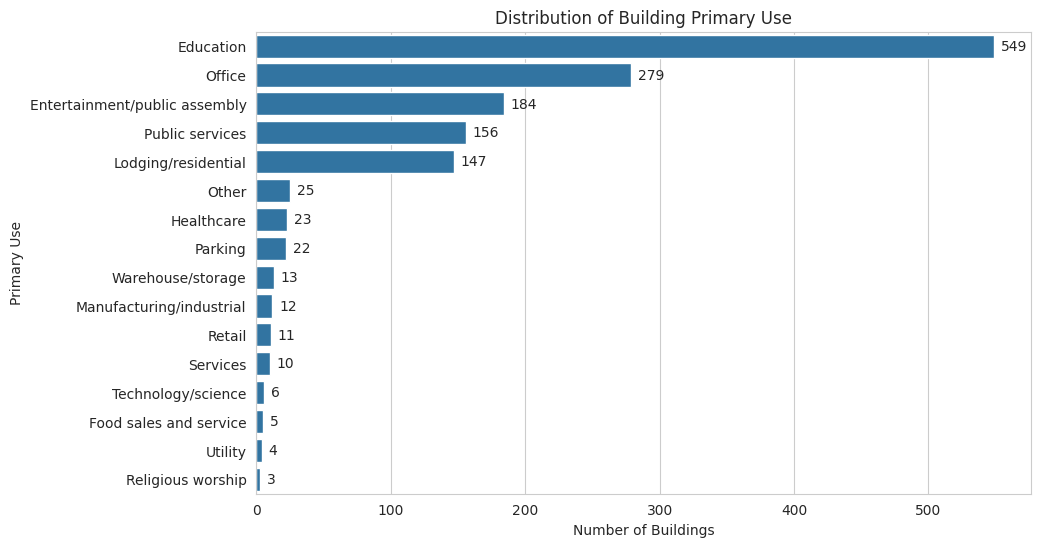

In [12]:
#Plot distribution of primary_use (16 building types)
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=building,
    y='primary_use',
    order=building['primary_use'].value_counts().index
)

plt.title("Distribution of Building Primary Use")
plt.xlabel("Number of Buildings")
plt.ylabel("Primary Use")

# ---- add counts on bars ----
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 5,                # position slightly right
        p.get_y() + p.get_height()/2,
        int(width),
        va='center'
    )

plt.show()

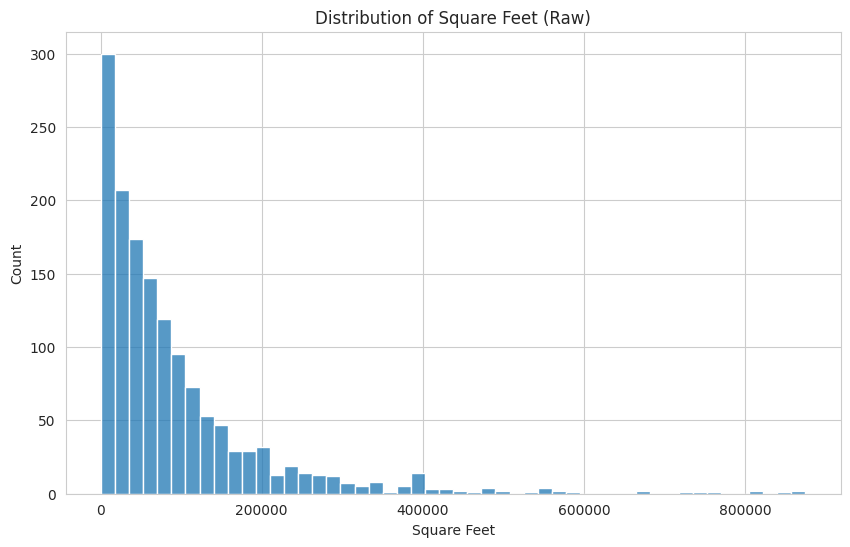

In [5]:
#Raw Distribution of square feet
plt.figure()

sns.histplot(building['square_feet'], bins=50)

plt.title("Distribution of Square Feet (Raw)")
plt.xlabel("Square Feet")
plt.ylabel("Count")

plt.show()

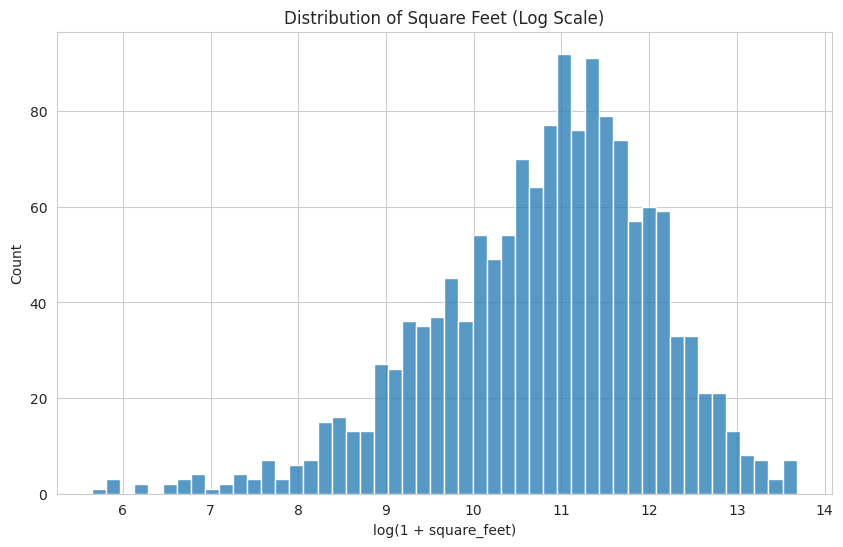

In [6]:
#Log Distribution of Square Feet
plt.figure()

sns.histplot(np.log1p(building['square_feet']), bins=50)

plt.title("Distribution of Square Feet (Log Scale)")
plt.xlabel("log(1 + square_feet)")
plt.ylabel("Count")

plt.show()

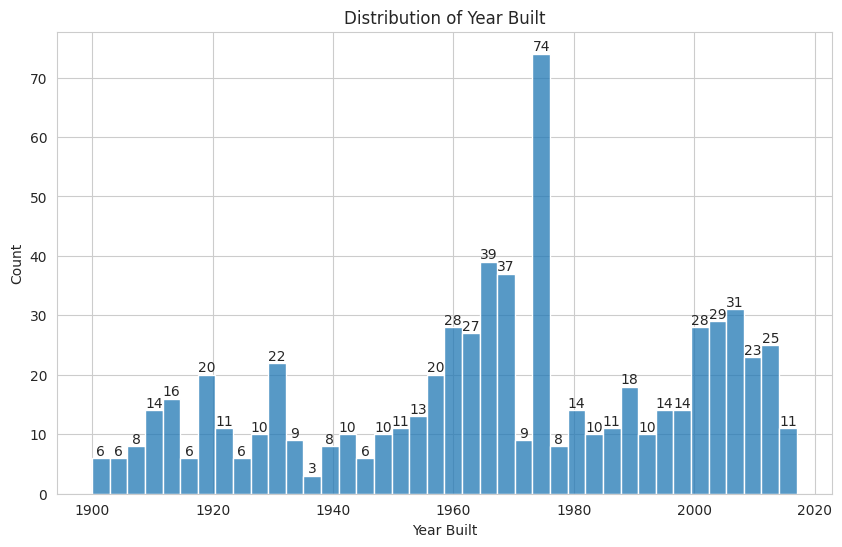

In [14]:
#Plot Distribution of year_built (non-missing only)
plt.figure(figsize=(10,6))

ax = sns.histplot(
    building['year_built'].dropna(),
    bins=40
)

plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Count")

# ---- add counts ----
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # avoid labeling empty bars
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            int(height),
            ha='center',
            va='bottom'
        )

plt.show()

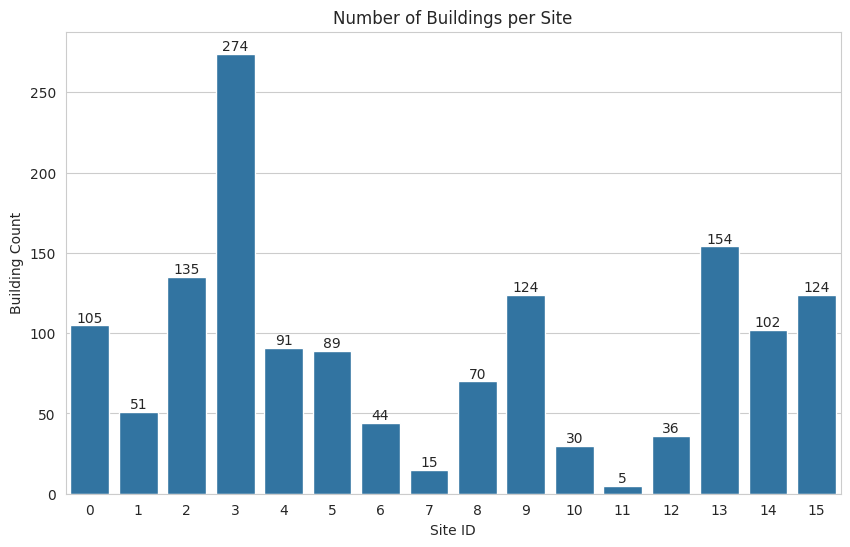

In [13]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=building,
    x='site_id',
    order=sorted(building['site_id'].unique())
)

plt.title("Number of Buildings per Site")
plt.xlabel("Site ID")
plt.ylabel("Building Count")

# ---- add counts ----
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 2,
        int(height),
        ha='center'
    )

plt.show()

**Key Findings**:
* Education has the highest number of buildings (38%)
* Religious worship, utility, food sales and service, and technology/science each have less than 10 buildings, so it might be better to delete those records
* log(1 + square_feet) scaling works good, values are within 14
* Many buildings were constructed between the 1960s and the 1980s.
* Site 11 only has 5 buildings

---

## Sprint 2 — Building Feature Engineering & Preprocessing

In [15]:
#Dropping floor count due to 75% missing values
try:
  building.drop(['floor_count'], axis=1, inplace = True)
except KeyError:
  print('Attributes already removed')

#checking if it's deleted or not
print(building.head(10))

   site_id  building_id          primary_use  square_feet  year_built
0        0            0            Education         7432      2008.0
1        0            1            Education         2720      2004.0
2        0            2            Education         5376      1991.0
3        0            3            Education        23685      2002.0
4        0            4            Education       116607      1975.0
5        0            5            Education         8000      2000.0
6        0            6  Lodging/residential        27926      1981.0
7        0            7            Education       121074      1989.0
8        0            8            Education        60809      2003.0
9        0            9               Office        27000      2010.0


In [16]:
# Imputing year_built using primary_use + site_id
building['year_built'] = building['year_built'].fillna(
    building.groupby(['primary_use', 'site_id'])['year_built']
               .transform('median')
)

# In case any of the previous groups had all null values, using only primary_use for median
building['year_built'].fillna(
    building.groupby('primary_use')['year_built']
               .transform('median'),
    inplace=True
)

# In case primary_use had any null values, using the overall median
building['year_built'].fillna(
    building['year_built'].median(),
    inplace=True
)

/tmp/ipython-input-4196202940.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  building['year_built'].fillna(
/tmp/ipython-input-4196202940.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({c

In [17]:
# One-hot encode primary_use
building = pd.get_dummies(
    building,
    columns=['primary_use'],
    prefix='use',
    drop_first=False   # keep all categories (tree models handle fine)
)
print(building.head(10))

   site_id  building_id  square_feet  year_built  use_Education  use_Entertainment/public assembly  use_Food sales and service  use_Healthcare  use_Lodging/residential  use_Manufacturing/industrial  use_Office  use_Other  use_Parking  use_Public services  use_Religious worship  use_Retail  use_Services  use_Technology/science  use_Utility  use_Warehouse/storage
0        0            0         7432      2008.0           True                              False                       False           False                    False                         False       False      False        False                False                  False       False         False                   False        False                  False
1        0            1         2720      2004.0           True                              False                       False           False                    False                         False       False      False        False                False                  

In [18]:
#Scaling square_feet feature using log1p
building['log_square_feet'] = np.log1p(building['square_feet'])

In [19]:
#Scaling year_built by calculating the age of the buildings
REFERENCE_YEAR = 2016  # ASHRAE dataset year

building['building_age'] = REFERENCE_YEAR - building['year_built']
building.head(10)

,site_id,building_id,square_feet,year_built,use_Education,use_Entertainment/public assembly,use_Food sales and service,use_Healthcare,use_Lodging/residential,use_Manufacturing/industrial,use_Office,use_Other,use_Parking,use_Public services,use_Religious worship,use_Retail,use_Services,use_Technology/science,use_Utility,use_Warehouse/storage,log_square_feet,building_age
0,0,0,7432,2008.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,8.913685,8.0
1,0,1,2720,2004.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,7.908755,12.0
2,0,2,5376,1991.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,8.589886,25.0
3,0,3,23685,2002.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,10.072639,14.0
4,0,4,116607,1975.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,11.666573,41.0
5,0,5,8000,2000.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,8.987322,16.0
6,0,6,27926,1981.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,10.237349,35.0
7,0,7,121074,1989.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,11.704165,27.0
8,0,8,60809,2003.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,11.015510,13.0
9,0,9,27000,2010.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,10.203629,6.0


In [20]:
#Dropping year_built and square_feet since they are no longer necessary
#building.drop(columns=['year_built'], inplace=True)
#building.drop(columns=['square_feet'], inplace=True)

In [21]:
#Confirming zero null remains in the dataset
print('\n---Information of the Building dataset --- \n')
print(building.info())


---Information of the Building dataset --- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   site_id                            1449 non-null   int64  
 1   building_id                        1449 non-null   int64  
 2   square_feet                        1449 non-null   int64  
 3   year_built                         1449 non-null   float64
 4   use_Education                      1449 non-null   bool   
 5   use_Entertainment/public assembly  1449 non-null   bool   
 6   use_Food sales and service         1449 non-null   bool   
 7   use_Healthcare                     1449 non-null   bool   
 8   use_Lodging/residential            1449 non-null   bool   
 9   use_Manufacturing/industrial       1449 non-null   bool   
 10  use_Office                         1449 non-null   bool   
 11  use_Other 

---

## Sprint 3 — Model Pipeline Contribution

---

## Sprint 4 — Evaluation & Report